# Tesis - MDM UBA - 2026

**Tariff classification using NLP**

By Santiago Tedoldi

# Scoring output - robust CV model comparison


In [1]:
import os
import json
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast

from hs04_distilbert_inference import HSClassifier


class HSDataset(Dataset):
    def __init__(self, dataframe, tokenizer, desc_col='', label_col='', max_length=500):
        self.descriptions = dataframe[desc_col].tolist()
        self.labels = dataframe[label_col].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.descriptions)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.descriptions[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': self.labels[idx],
            'description': self.descriptions[idx]
        }
        return item


# Function to extract [CLS] embeddings
def get_embeddings(dataloader, model, device):
    all_embeds = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attn = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attn)
            # DistilBERT does not have pooler; use first token hidden state
            cls_embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeds.append(cls_embeds)
            all_labels.extend(batch['label'])
    return np.vstack(all_embeds), np.array(all_labels)


dtypes = {
    'Description': str,
    'True Label': str,
    'Top1': str,
    'Top2': str,
    'Top3': str,
    'Top4': str,
    'Top5': str,
}

results_finetuned = pd.read_csv(
    'results/distilbert/fft_final/final_val_predictions.csv',
    index_col=0,
    dtype=dtypes,
)

In [2]:
torch.cuda.empty_cache()

Loading models

In [3]:
# loading final model artifacts
with open('results/distilbert/fft_final/final_model/training_config.json', 'r') as f:
    model_config = json.load(f)

with open('results/distilbert/fft_final/labels/labels_dict_FINAL_DBERT_fft_GOODS_DESCRIPTION_HS04_seed32.json', 'r') as f:
    labels_dict = json.load(f)

label2id = labels_dict['label2id']
id2label = {int(k): v for k, v in labels_dict['id2label'].items()}

# loading tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# loading final model
model_path = 'results/distilbert/fft_final/final_model/pytorch_model.bin'
model_final = HSClassifier(
    n_classes=len(label2id),
    fine_tune=model_config.get('fine_tune', False),
    n_finetune_layers=model_config.get('n_finetune_layers', 0),
)

state_dict = torch.load(model_path, map_location='cpu')
model_final.load_state_dict(state_dict)

# Keep legacy variable names to avoid downstream code changes
model_finetuned2 = model_final
model_finetuned = model_final

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model_final.to(device)
model_final.eval()  # to set the model for inference


C:\Users\santt\AppData\Local\Temp\ipykernel_8720\1994254139.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location='cpu')


Using device: cuda


HSClassifier(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Lin

Getting test embeddings

In [4]:
# results_finetuned
ds = HSDataset(
    results_finetuned,
    tokenizer,
    desc_col='Description',
    label_col='True Label',
    max_length=model_config['max_length'],
)

loader = DataLoader(ds, batch_size=128, shuffle=False)

embeds_finetuned, labels_finetuned = get_embeddings(loader, model_final.distilbert, device)
print('Embeddings shape:', embeds_finetuned.shape)


Embeddings shape: (2677, 768)


Merging with HS06 nomenclature

In [5]:
df_hs06 = pd.read_csv(
    'data/hs06_full_eng.csv',
    dtype={'hs06': str, 'full_eng': str},
    usecols=['hs06', 'full_eng'],
)

# Build a single legal-text row per HS04 (first available HS06 description per HS04)
df_hs04_text = (
    df_hs06.assign(hs04=df_hs06['hs06'].astype(str).str[:4])
    .dropna(subset=['full_eng'])
    .drop_duplicates(subset=['hs04'], keep='first')
    .loc[:, ['hs04', 'full_eng']]
    .rename(columns={'hs04': 'True Label'})
)

# Embed HS04 legal text so we can compute desc-vs-legal cosine similarity
ds_full_eng = HSDataset(
    df_hs04_text.rename(columns={'full_eng': 'Description'}),
    tokenizer,
    desc_col='Description',
    label_col='True Label',
    max_length=model_config['max_length'],
)
loader_full_eng = DataLoader(ds_full_eng, batch_size=128, shuffle=False)
embeds_full_eng, labels_full_eng = get_embeddings(loader_full_eng, model_final.distilbert, device)
print('HS04 legal-text embeddings shape:', embeds_full_eng.shape)

# Merge legal text into scored predictions
df_hs04_text = df_hs04_text.set_index('True Label')
results_finetuned = pd.merge(results_finetuned, df_hs04_text, how='left', left_on='True Label', right_index=True)


HS04 legal-text embeddings shape: (942, 768)


### Legal-text similarity for true label and Top1-Top5 predictions

The previous notebook version used a cosine similarity between the description and the legal text of the `True Label`.
That variable is useful for diagnosis, but it is not production-safe because the ground-truth label is unknown at inference time.

In this version:

- `cosine_sim_desc_vs_true_hs_text` is kept only for diagnostics,
- `cosine_sim_desc_vs_top1_hs_text` to `cosine_sim_desc_vs_top5_hs_text` are computed and used as candidate production features.


In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

hs04_to_hsvec = {
    str(hs_code): emb
    for hs_code, emb in zip(labels_full_eng, embeds_full_eng)
}


def cosine_similarity_to_code(
    desc_vec: np.ndarray,
    hs_code: str,
    embedding_map: dict[str, np.ndarray],
) -> float:
    hs_vec = embedding_map.get(str(hs_code))
    if hs_vec is None:
        return np.nan
    return float(
        cosine_similarity(
            desc_vec.reshape(1, -1),
            hs_vec.reshape(1, -1),
        )[0][0]
    )


In [7]:
def add_legal_text_similarity_features(
    df: pd.DataFrame,
    desc_embeddings: np.ndarray,
    embedding_map: dict[str, np.ndarray],
    true_label_col: str = "True Label",
    top_cols: list[str] | None = None,
) -> pd.DataFrame:
    if top_cols is None:
        top_cols = [f"Top{i}" for i in range(1, 6)]

    out = df.copy()
    out["cosine_sim_desc_vs_true_hs_text"] = np.nan

    for top_col in top_cols:
        out[f"cosine_sim_desc_vs_{top_col.lower()}_hs_text"] = np.nan

    for row_pos, (_, row) in enumerate(out.iterrows()):
        desc_vec = desc_embeddings[row_pos]
        out.at[row.name, "cosine_sim_desc_vs_true_hs_text"] = cosine_similarity_to_code(
            desc_vec,
            row[true_label_col],
            embedding_map,
        )

        for top_col in top_cols:
            out.at[row.name, f"cosine_sim_desc_vs_{top_col.lower()}_hs_text"] = cosine_similarity_to_code(
                desc_vec,
                row[top_col],
                embedding_map,
            )

    return out


results_finetuned = add_legal_text_similarity_features(
    results_finetuned,
    embeds_finetuned,
    hs04_to_hsvec,
)


In [8]:
similarity_cols = [
    "cosine_sim_desc_vs_true_hs_text",
    *[f"cosine_sim_desc_vs_top{i}_hs_text" for i in range(1, 6)],
]
results_finetuned[["True Label", "Top1", "Top2", "Top3", "Top4", "Top5", *similarity_cols]].head()


,True Label,Top1,Top2,Top3,Top4,Top5,cosine_sim_desc_vs_true_hs_text,cosine_sim_desc_vs_top1_hs_text,cosine_sim_desc_vs_top2_hs_text,cosine_sim_desc_vs_top3_hs_text,cosine_sim_desc_vs_top4_hs_text,cosine_sim_desc_vs_top5_hs_text
354196,8419,9402,9403,9018,8419,8537,0.404270,0.701359,0.493955,0.432439,0.404270,0.502662
155635,3303,3303,3307,3302,3301,3304,NaN,NaN,0.654653,0.603302,0.500653,0.502607
134060,3920,8546,3919,5906,3920,3921,0.485572,0.498096,0.531143,0.558025,0.485572,0.457375
114018,8482,8482,8483,7319,8711,7009,0.829166,0.829166,0.457289,0.354707,0.501478,0.369798
264869,9403,9403,9401,9404,8715,9402,0.636881,0.636881,0.706738,0.590968,NaN,0.615729


### Feature engineering

To reduce overfitting risk, the meta-model now starts from a more compact feature pool:

- calibrated probability features,
- similarity features for `Top1` to `Top5`,
- a limited set of summary statistics,
- no ground-truth-only features in the production feature set.


In [9]:
def create_meta_model_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    prob_cols = [f"Proba Top{i}" for i in range(1, 6)]
    cosine_cols = [f"cosine_sim_desc_vs_top{i}_hs_text" for i in range(1, 6)]

    probs = df[prob_cols].astype(float)
    probs_nonneg = probs.clip(lower=0)
    prob_sum = probs_nonneg.sum(axis=1).replace(0, np.nan)
    probs_norm = probs_nonneg.div(prob_sum, axis=0).fillna(0.0)

    df["prob_mean"] = probs.mean(axis=1)
    df["prob_max"] = probs.max(axis=1)
    df["prob_min"] = probs.min(axis=1)
    df["prob_range"] = df["prob_max"] - df["prob_min"]
    df["prob_std"] = probs.std(axis=1)
    df["prob_margin_1_2"] = df["Proba Top1"] - df["Proba Top2"]
    df["prob_margin_1_3"] = df["Proba Top1"] - df["Proba Top3"]

    entropy = -(probs_norm * np.log(probs_norm.clip(lower=1e-12))).sum(axis=1)
    df["prob_entropy"] = entropy
    df["prob_entropy_norm"] = entropy / np.log(len(prob_cols))

    rank_weights = np.arange(5, 0, -1)
    df["prob_weighted_rank_score"] = probs_nonneg.mul(rank_weights, axis=1).sum(axis=1) / prob_sum

    cosine_df = df[cosine_cols].astype(float)
    df["cosine_pred_mean"] = cosine_df.mean(axis=1)
    df["cosine_pred_max"] = cosine_df.max(axis=1)
    df["cosine_pred_min"] = cosine_df.min(axis=1)
    df["cosine_pred_range"] = df["cosine_pred_max"] - df["cosine_pred_min"]
    df["cosine_pred_std"] = cosine_df.std(axis=1)
    df["cosine_margin_1_2"] = (
        df["cosine_sim_desc_vs_top1_hs_text"] - df["cosine_sim_desc_vs_top2_hs_text"]
    )
    cosine_values = cosine_df.fillna(0.0).to_numpy()
    prob_values = probs_norm.to_numpy()
    df["cosine_weighted_by_proba"] = (prob_values * cosine_values).sum(axis=1)
    df["joint_top1_signal"] = (
        df["Proba Top1"] * df["cosine_sim_desc_vs_top1_hs_text"]
    )

    return df


results_finetuned = create_meta_model_features(results_finetuned)


In [10]:
PROBA_FEATURES = [
    "Proba Top1",
    "Proba Top2",
    "Proba Top3",
    "Proba Top4",
    "Proba Top5",
    "prob_std",
    "prob_range",
    "prob_margin_1_2",
    "prob_margin_1_3",
    "prob_entropy_norm",
    "prob_weighted_rank_score",
]

COSINE_FEATURES = [
    "cosine_sim_desc_vs_top1_hs_text",
    "cosine_sim_desc_vs_top2_hs_text",
    "cosine_sim_desc_vs_top3_hs_text",
    "cosine_sim_desc_vs_top4_hs_text",
    "cosine_sim_desc_vs_top5_hs_text",
    "cosine_pred_mean",
    "cosine_pred_std",
    "cosine_pred_range",
    "cosine_margin_1_2",
    "cosine_weighted_by_proba",
    "joint_top1_signal",
]

ANALYSIS_ONLY_FEATURES = [
    "cosine_sim_desc_vs_true_hs_text",
]

CANDIDATE_FEATURES = PROBA_FEATURES + COSINE_FEATURES

pd.DataFrame(
    {
        "feature": CANDIDATE_FEATURES + ANALYSIS_ONLY_FEATURES,
        "group": (
            ["probability"] * len(PROBA_FEATURES)
            + ["predicted_legal_text_similarity"] * len(COSINE_FEATURES)
            + ["diagnostic_only_excluded_from_model"] * len(ANALYSIS_ONLY_FEATURES)
        ),
    }
)


,feature,group
0,Proba Top1,probability
1,Proba Top2,probability
2,Proba Top3,probability
3,Proba Top4,probability
4,Proba Top5,probability
5,prob_std,probability
6,prob_range,probability
7,prob_margin_1_2,probability
8,prob_margin_1_3,probability
9,prob_entropy_norm,probability


### Classification score

This notebook now compares both target scales for the confidence meta-model:

- `score_10`: `Top1 -> 10`, `Top2 -> 9`, `Top3 -> 8`, `Top4 -> 7`, `Top5 -> 6`, otherwise `0`
- `score_5`: `Top1 -> 5`, `Top2 -> 4`, `Top3 -> 3`, `Top4 -> 2`, `Top5 -> 1`, otherwise `0`

The rest of the notebook evaluates which target scale is more useful for separating good vs rejected cases.


In [11]:
def assign_score_columns_and_topn_flags(
    df: pd.DataFrame,
    true_label_col: str = "True Label",
    top_prefix: str = "Top",
    max_rank: int = 5,
) -> pd.DataFrame:
    df = df.copy()

    def _get_rank(row):
        true_label = row[true_label_col]
        if pd.isna(true_label):
            return np.nan

        for rank in range(1, max_rank + 1):
            pred_label = row.get(f"{top_prefix}{rank}")
            if pd.notna(pred_label) and true_label == pred_label:
                return rank

        return np.nan

    ranks = pd.to_numeric(df.apply(_get_rank, axis=1), errors="coerce")

    df["score_10"] = (11 - ranks).where(ranks.notna(), 0).astype(int)
    df["score_5"] = (6 - ranks).where(ranks.notna(), 0).astype(int)

    for k in range(1, max_rank + 1):
        cols = [f"{top_prefix}{i}" for i in range(1, k + 1)]
        df[f"top{k}_true"] = (
            df[cols]
            .eq(df[true_label_col], axis=0)
            .fillna(False)
            .any(axis=1)
            .astype(int)
        )

    return df


In [12]:
results_finetuned = assign_score_columns_and_topn_flags(results_finetuned)

df_score_distributions = pd.DataFrame(
    {
        "score_10": results_finetuned["score_10"].value_counts(dropna=False).sort_index(),
        "score_5": results_finetuned["score_5"].value_counts(dropna=False).sort_index(),
    }
).fillna(0).astype(int)

df_score_distributions


,score_10,score_5
0,433,433
1,0,48
2,0,63
3,0,113
4,0,234
5,0,1786
6,48,0
7,63,0
8,113,0
9,234,0


### Robust confidence meta-model comparison

Both target scales are evaluated with repeated cross-validation and the same production-safe feature set.

Main ideas:

- repeated CV to reduce dependence on a single hold-out sample,
- train-fold-only feature filtering to lower overfitting risk,
- model comparison for both score scales,
- threshold tuning per model and per score scale,
- confusion matrices based on out-of-fold predictions.


In [13]:
from collections import Counter, defaultdict

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError:
    XGBRegressor = None
    print("xgboost is not installed. Install it in the active kernel to include XGBoostRegressor.")

RANDOM_STATE = 42
CV_N_REPEATS = 10
CV_MAX_SPLITS = 5
MAX_SELECTED_FEATURES = 10
CORR_THRESHOLD = 0.90
TRUE_GOOD_SCORE_THRESHOLD = 0.0

SCORE_SCHEMES = [
    {
        "scheme": "score_10",
        "label": "10_to_0",
        "target_col": "score_10",
        "valid_scores": [0, 6, 7, 8, 9, 10],
        "threshold_grid": [0.5, 5.5, 6.5, 7.5, 8.5, 9.5],
    },
    {
        "scheme": "score_5",
        "label": "5_to_0",
        "target_col": "score_5",
        "valid_scores": [0, 1, 2, 3, 4, 5],
        "threshold_grid": [0.5, 1.5, 2.5, 3.5, 4.5],
    },
]


def build_model_specs(random_state: int = 42):
    specs = [
        (
            "HistGradientBoosting",
            "pred_hgb",
            HistGradientBoostingRegressor(random_state=random_state),
        ),
        (
            "RandomForest",
            "pred_rf",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=4,
                random_state=random_state,
                n_jobs=-1,
            ),
        ),
    ]

    if XGBRegressor is not None:
        specs.append(
            (
                "XGBoost",
                "pred_xgb",
                XGBRegressor(
                    n_estimators=250,
                    max_depth=4,
                    learning_rate=0.04,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=1.0,
                    reg_lambda=2.0,
                    min_child_weight=5,
                    objective="reg:squarederror",
                    random_state=random_state,
                    n_jobs=-1,
                ),
            )
        )

    return specs


def prepare_feature_matrix(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def correlation_mi_feature_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    corr_threshold: float = 0.90,
    max_features: int = 10,
    random_state: int = 42,
):
    X = X_train.copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    constant_cols = X.columns[X.nunique(dropna=False) <= 1].tolist()
    if constant_cols:
        X = X.drop(columns=constant_cols)

    X = X.fillna(X.median(numeric_only=True))

    if X.shape[1] == 0:
        raise ValueError("No candidate features available after removing constant columns.")

    mi_values = mutual_info_regression(X, y_train, random_state=random_state)
    mi_scores = pd.Series(mi_values, index=X.columns).fillna(0.0)

    corr = X.corr().abs().fillna(0.0)
    pairs = []
    for i, feature_i in enumerate(corr.columns):
        for j in range(i + 1, len(corr.columns)):
            feature_j = corr.columns[j]
            corr_value = corr.iloc[i, j]
            if corr_value >= corr_threshold:
                pairs.append((corr_value, feature_i, feature_j))

    pairs.sort(reverse=True)

    removed = set()
    for corr_value, feature_i, feature_j in pairs:
        if feature_i in removed or feature_j in removed:
            continue
        keep = feature_i if mi_scores[feature_i] >= mi_scores[feature_j] else feature_j
        drop = feature_j if keep == feature_i else feature_i
        removed.add(drop)

    selected = [feature for feature in X.columns if feature not in removed]
    selected = (
        mi_scores.loc[selected]
        .sort_values(ascending=False)
        .head(min(max_features, len(selected)))
        .index
        .tolist()
    )

    return selected


def evaluate_threshold_predictions(
    y_true: pd.Series,
    y_pred: np.ndarray,
    pred_threshold: float,
    true_good_threshold: float = 0.0,
) -> dict:
    y_true = pd.Series(y_true).astype(float)
    y_pred = np.asarray(y_pred, dtype=float)

    accept_mask = y_pred > pred_threshold
    good_mask = y_true.to_numpy() > true_good_threshold
    bad_mask = ~good_mask

    baseline_precision_good_pct = 100 * good_mask.mean()

    if accept_mask.sum() > 0:
        precision_good_pct = 100 * good_mask[accept_mask].mean()
    else:
        precision_good_pct = np.nan

    return {
        "pred_threshold": pred_threshold,
        "coverage_pct": 100 * accept_mask.mean(),
        "precision_good_pct": precision_good_pct,
        "baseline_precision_good_pct": baseline_precision_good_pct,
        "precision_lift_vs_baseline_pp": precision_good_pct - baseline_precision_good_pct
        if not np.isnan(precision_good_pct)
        else np.nan,
        "good_case_recall_pct": (
            100 * ((accept_mask & good_mask).sum() / good_mask.sum())
            if good_mask.sum()
            else np.nan
        ),
        "bad_case_filter_pct": (
            100 * (((~accept_mask) & bad_mask).sum() / bad_mask.sum())
            if bad_mask.sum()
            else np.nan
        ),
    }


def summarize_mean_std(df: pd.DataFrame, group_cols: list[str], metric_cols: list[str]) -> pd.DataFrame:
    summary = (
        df.groupby(group_cols)[metric_cols]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = [
        "_".join([part for part in col if part]).rstrip("_")
        for col in summary.columns.to_flat_index()
    ]
    return summary


def snap_predictions_to_allowed_scores(y_pred: np.ndarray, valid_scores: list[int]) -> np.ndarray:
    allowed = np.array(valid_scores, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    snapped = allowed[np.abs(y_pred.reshape(-1, 1) - allowed.reshape(1, -1)).argmin(axis=1)]
    return snapped.astype(int)


def plot_predicted_violin(y_true, y_pred, title="Predicted Score Distribution by True Score"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    unique_scores = np.unique(y_true)
    data = [y_pred[y_true == score] for score in unique_scores]

    plt.figure(figsize=(8, 6))
    plt.violinplot(data, positions=unique_scores, showmeans=True)
    plt.xlabel("True Score")
    plt.ylabel("Predicted Score")
    plt.title(title)
    plt.xticks(unique_scores)
    plt.tight_layout()
    plt.show()


In [14]:
X_all = prepare_feature_matrix(results_finetuned, CANDIDATE_FEATURES)
MODEL_SPECS = build_model_specs(random_state=RANDOM_STATE)

fold_rows = []
threshold_rows = []
feature_rows = []
feature_counter = Counter()
oof_predictions = {}

for scheme in SCORE_SCHEMES:
    target_col = scheme["target_col"]
    y_all = results_finetuned[target_col].astype(int)
    min_class_count = int(y_all.value_counts().min())

    if min_class_count >= 2:
        cv_n_splits = min(CV_MAX_SPLITS, min_class_count)
        splitter = RepeatedStratifiedKFold(
            n_splits=cv_n_splits,
            n_repeats=CV_N_REPEATS,
            random_state=RANDOM_STATE,
        )
        split_iterator = splitter.split(X_all, y_all)
        cv_strategy_name = f"RepeatedStratifiedKFold(n_splits={cv_n_splits}, n_repeats={CV_N_REPEATS})"
    else:
        cv_n_splits = min(CV_MAX_SPLITS, max(2, len(X_all) // 10))
        splitter = RepeatedKFold(
            n_splits=cv_n_splits,
            n_repeats=CV_N_REPEATS,
            random_state=RANDOM_STATE,
        )
        split_iterator = splitter.split(X_all)
        cv_strategy_name = f"RepeatedKFold(n_splits={cv_n_splits}, n_repeats={CV_N_REPEATS})"

    print(f"Running scheme {scheme['label']} with {cv_strategy_name}")

    for model_name, prediction_stub, _ in MODEL_SPECS:
        prediction_col = f"{scheme['scheme']}_{prediction_stub}"
        oof_predictions[prediction_col] = defaultdict(list)

    for fold_id, (train_idx, valid_idx) in enumerate(split_iterator, start=1):
        X_train_raw = X_all.iloc[train_idx].copy()
        X_valid_raw = X_all.iloc[valid_idx].copy()
        y_train = y_all.iloc[train_idx].copy()
        y_valid = y_all.iloc[valid_idx].copy()

        selected_features = correlation_mi_feature_filter(
            X_train_raw,
            y_train,
            corr_threshold=CORR_THRESHOLD,
            max_features=MAX_SELECTED_FEATURES,
            random_state=RANDOM_STATE + fold_id,
        )

        for feature_name in selected_features:
            feature_counter[(scheme["scheme"], feature_name)] += 1

        feature_rows.append(
            {
                "scheme": scheme["label"],
                "fold": fold_id,
                "n_selected_features": len(selected_features),
                "selected_features": ", ".join(selected_features),
            }
        )

        X_train = X_train_raw[selected_features].copy()
        X_valid = X_valid_raw[selected_features].copy()
        train_medians = X_train.median(numeric_only=True)
        X_train = X_train.fillna(train_medians)
        X_valid = X_valid.fillna(train_medians)

        for model_name, prediction_stub, model in MODEL_SPECS:
            prediction_col = f"{scheme['scheme']}_{prediction_stub}"
            fitted_model = clone(model)
            fitted_model.fit(X_train, y_train)
            y_pred = np.clip(
                fitted_model.predict(X_valid),
                min(scheme["valid_scores"]),
                max(scheme["valid_scores"]),
            )

            for idx, pred in zip(X_valid.index, y_pred):
                oof_predictions[prediction_col][idx].append(float(pred))

            fold_rows.append(
                {
                    "scheme": scheme["label"],
                    "target_col": target_col,
                    "model": model_name,
                    "prediction_col": prediction_col,
                    "mae": mean_absolute_error(y_valid, y_pred),
                    "rmse": np.sqrt(mean_squared_error(y_valid, y_pred)),
                    "r2": r2_score(y_valid, y_pred),
                    "n_selected_features": len(selected_features),
                }
            )

            for pred_threshold in scheme["threshold_grid"]:
                row = evaluate_threshold_predictions(
                    y_valid,
                    y_pred,
                    pred_threshold=pred_threshold,
                    true_good_threshold=TRUE_GOOD_SCORE_THRESHOLD,
                )
                row.update(
                    {
                        "scheme": scheme["label"],
                        "target_col": target_col,
                        "model": model_name,
                        "prediction_col": prediction_col,
                    }
                )
                threshold_rows.append(row)

df_fold_metrics = pd.DataFrame(fold_rows)
df_threshold_metrics = pd.DataFrame(threshold_rows)
df_fold_feature_sets = pd.DataFrame(feature_rows)

total_folds_by_scheme = df_fold_feature_sets.groupby("scheme").size().to_dict()
df_feature_selection_frequency = (
    pd.DataFrame(
        [
            {
                "scheme": scheme["label"],
                "feature": feature,
                "times_selected": feature_counter.get((scheme["scheme"], feature), 0),
                "selection_pct": 100
                * feature_counter.get((scheme["scheme"], feature), 0)
                / total_folds_by_scheme[scheme["label"]],
            }
            for scheme in SCORE_SCHEMES
            for feature in CANDIDATE_FEATURES
        ]
    )
    .sort_values(["scheme", "selection_pct", "feature"], ascending=[True, False, True])
    .reset_index(drop=True)
)

df_cv_regression_summary = summarize_mean_std(
    df_fold_metrics,
    group_cols=["scheme", "target_col", "model", "prediction_col"],
    metric_cols=["mae", "rmse", "r2", "n_selected_features"],
).sort_values(["scheme", "rmse_mean", "mae_mean", "r2_mean"], ascending=[True, True, True, False])

df_cv_threshold_summary = summarize_mean_std(
    df_threshold_metrics,
    group_cols=["scheme", "target_col", "model", "prediction_col", "pred_threshold"],
    metric_cols=[
        "coverage_pct",
        "precision_good_pct",
        "baseline_precision_good_pct",
        "precision_lift_vs_baseline_pp",
        "good_case_recall_pct",
        "bad_case_filter_pct",
    ],
)

df_cv_threshold_summary["threshold_utility_score"] = (
    0.35 * df_cv_threshold_summary["precision_good_pct_mean"]
    + 0.20 * df_cv_threshold_summary["precision_lift_vs_baseline_pp_mean"]
    + 0.20 * df_cv_threshold_summary["good_case_recall_pct_mean"]
    + 0.15 * df_cv_threshold_summary["bad_case_filter_pct_mean"]
    + 0.10 * df_cv_threshold_summary["coverage_pct_mean"]
)

df_best_threshold_by_model = (
    df_cv_threshold_summary.sort_values(
        [
            "scheme",
            "model",
            "threshold_utility_score",
            "precision_good_pct_mean",
            "coverage_pct_mean",
        ],
        ascending=[True, True, False, False, False],
    )
    .groupby(["scheme", "model"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

df_oof_eval = results_finetuned.copy()
for scheme in SCORE_SCHEMES:
    target_col = scheme["target_col"]
    df_oof_eval[f"{scheme['scheme']}_true"] = results_finetuned[target_col].astype(int)
    for model_name, prediction_stub, _ in MODEL_SPECS:
        prediction_col = f"{scheme['scheme']}_{prediction_stub}"
        df_oof_eval[prediction_col] = (
            df_oof_eval.index.to_series()
            .map(lambda idx: np.mean(oof_predictions[prediction_col][idx]) if oof_predictions[prediction_col][idx] else np.nan)
        )


Running scheme 10_to_0 with RepeatedStratifiedKFold(n_splits=5, n_repeats=10)
Running scheme 5_to_0 with RepeatedStratifiedKFold(n_splits=5, n_repeats=10)


In [15]:
df_feature_selection_frequency

,scheme,feature,times_selected,selection_pct
0,10_to_0,Proba Top2,50,100.0
1,10_to_0,Proba Top3,50,100.0
2,10_to_0,Proba Top5,50,100.0
3,10_to_0,cosine_sim_desc_vs_top1_hs_text,50,100.0
4,10_to_0,cosine_weighted_by_proba,50,100.0
5,10_to_0,joint_top1_signal,50,100.0
6,10_to_0,Proba Top4,49,98.0
7,10_to_0,cosine_pred_mean,42,84.0
8,10_to_0,prob_range,40,80.0
9,10_to_0,cosine_margin_1_2,27,54.0


In [18]:
df_feature_selection_frequency_top = (
    df_feature_selection_frequency
    .sort_values(["scheme", "selection_pct", "times_selected"], ascending=[True, False, False])
    .groupby("scheme", as_index=False)
    .head(10)
    .reset_index(drop=True)
)

df_feature_selection_frequency_top.round(3)

,scheme,feature,times_selected,selection_pct
0,10_to_0,Proba Top2,50,100.0
1,10_to_0,Proba Top3,50,100.0
2,10_to_0,Proba Top5,50,100.0
3,10_to_0,cosine_sim_desc_vs_top1_hs_text,50,100.0
4,10_to_0,cosine_weighted_by_proba,50,100.0
5,10_to_0,joint_top1_signal,50,100.0
6,10_to_0,Proba Top4,49,98.0
7,10_to_0,cosine_pred_mean,42,84.0
8,10_to_0,prob_range,40,80.0
9,10_to_0,cosine_margin_1_2,27,54.0


In [ ]:
df_feature_selection_frequency_top.round(3).to_clipboard(index=False, excel=True)

In [29]:
df_cv_regression_summary.round(4)

,scheme,target_col,model,prediction_col,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,n_selected_features_mean,n_selected_features_std
1,10_to_0,score_10,RandomForest,score_10_pred_rf,1.9543,0.0641,3.0343,0.0950,0.3018,0.0437,10.0,0.0
2,10_to_0,score_10,XGBoost,score_10_pred_xgb,1.9658,0.0728,3.0871,0.1084,0.2770,0.0509,10.0,0.0
0,10_to_0,score_10,HistGradientBoosting,score_10_pred_hgb,2.0124,0.0788,3.2094,0.1180,0.2185,0.0576,10.0,0.0
4,5_to_0,score_5,RandomForest,score_5_pred_rf,1.0347,0.0375,1.5273,0.0513,0.3399,0.0441,10.0,0.0
5,5_to_0,score_5,XGBoost,score_5_pred_xgb,1.0389,0.0400,1.5533,0.0551,0.3171,0.0482,10.0,0.0
3,5_to_0,score_5,HistGradientBoosting,score_5_pred_hgb,1.0578,0.0401,1.6139,0.0585,0.2628,0.0532,10.0,0.0


In [31]:
df_cv_regression_summary.T.round(3).to_clipboard(index=False, excel=True)

In [32]:
df_best_threshold_by_model[
    [
        "scheme",
        "model",
        "prediction_col",
        "pred_threshold",
        "threshold_utility_score",
        "coverage_pct_mean",
        "precision_good_pct_mean",
        "precision_lift_vs_baseline_pp_mean",
        "good_case_recall_pct_mean",
        "bad_case_filter_pct_mean",
    ]
].round(3)


,scheme,model,prediction_col,pred_threshold,threshold_utility_score,coverage_pct_mean,precision_good_pct_mean,precision_lift_vs_baseline_pp_mean,good_case_recall_pct_mean,bad_case_filter_pct_mean
0,10_to_0,HistGradientBoosting,score_10_pred_hgb,7.5,66.710,70.702,92.394,8.569,77.919,66.693
1,10_to_0,RandomForest,score_10_pred_rf,7.5,68.097,68.577,93.818,9.992,76.738,73.711
2,10_to_0,XGBoost,score_10_pred_xgb,7.5,67.354,70.721,92.859,9.034,78.333,68.721
3,5_to_0,HistGradientBoosting,score_5_pred_hgb,3.5,66.951,70.351,92.637,8.812,77.731,67.894
4,5_to_0,RandomForest,score_5_pred_rf,3.5,67.852,69.074,93.541,9.715,77.063,72.329
5,5_to_0,XGBoost,score_5_pred_xgb,3.5,67.479,70.336,93.020,9.195,78.043,69.603


In [34]:
df_best_threshold_by_model[
    [
        "scheme",
        "model",
        "prediction_col",
        "pred_threshold",
        "threshold_utility_score",
        "coverage_pct_mean",
        "precision_good_pct_mean",
        "precision_lift_vs_baseline_pp_mean",
        "good_case_recall_pct_mean",
        "bad_case_filter_pct_mean",
    ]
].T.round(3).to_clipboard(index=False, excel=True)

In [35]:
df_best_threshold_by_model[
    [
        "scheme",
        "model",
        "prediction_col",
        "pred_threshold",
        "threshold_utility_score",
        "coverage_pct_mean",
        "precision_good_pct_mean",
        "precision_lift_vs_baseline_pp_mean",
        "good_case_recall_pct_mean",
        "bad_case_filter_pct_mean",
    ]
].round(3).to_clipboard(index=False, excel=True)

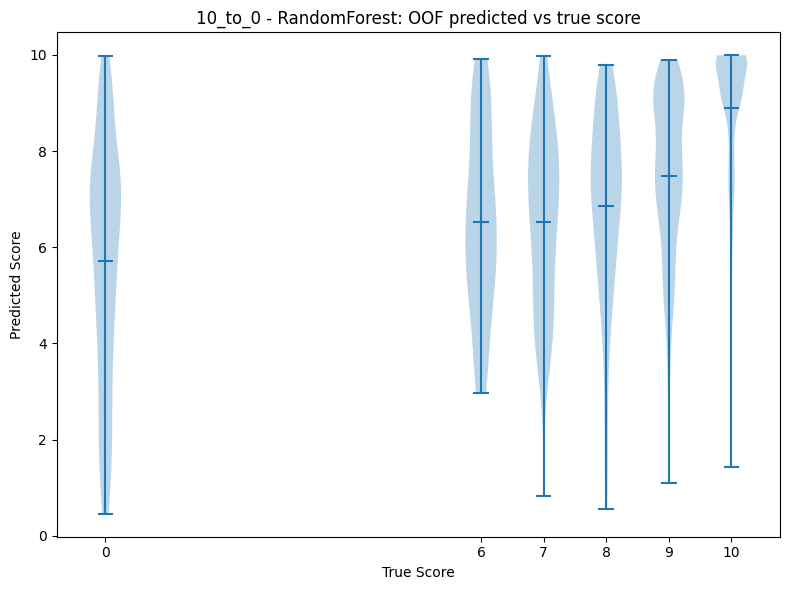

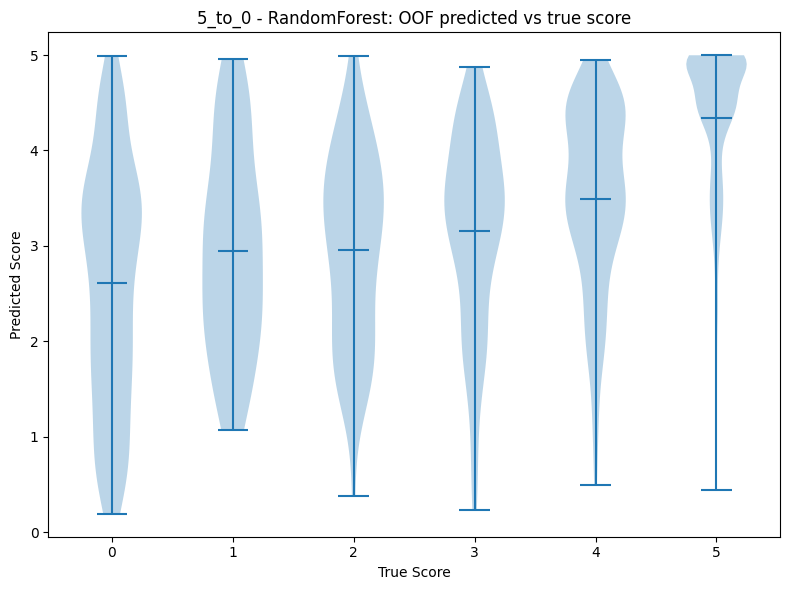

In [37]:
for scheme in SCORE_SCHEMES:
    best_row = (
        df_cv_regression_summary.loc[df_cv_regression_summary["scheme"] == scheme["label"]]
        .sort_values(["rmse_mean", "mae_mean", "r2_mean"], ascending=[True, True, False])
        .iloc[0]
    )
    valid_mask = df_oof_eval[best_row["prediction_col"]].notna()
    plot_predicted_violin(
        df_oof_eval.loc[valid_mask, f"{scheme['scheme']}_true"],
        df_oof_eval.loc[valid_mask, best_row["prediction_col"]],
        title=f"{scheme['label']} - {best_row['model']}: OOF predicted vs true score",
    )


### Scale and model recommendation

This table compares all combinations of score scale and regressor.
It helps choose both:

- the target scale (`10_to_0` vs `5_to_0`)
- the meta-model to take to production


In [38]:
df_scale_model_recommendation = (
    df_cv_regression_summary.merge(
        df_best_threshold_by_model,
        on=["scheme", "target_col", "model", "prediction_col"],
        how="left",
    )
    .copy()
)

rank_config = {
    "rmse_mean": True,
    "mae_mean": True,
    "r2_mean": False,
    "threshold_utility_score": False,
    "precision_lift_vs_baseline_pp_mean": False,
}

for metric_name, ascending in rank_config.items():
    df_scale_model_recommendation[f"rank_{metric_name}"] = df_scale_model_recommendation.groupby("scheme")[metric_name].rank(
        ascending=ascending,
        method="min",
    )

df_scale_model_recommendation["production_rank_score"] = (
    0.30 * df_scale_model_recommendation["rank_rmse_mean"]
    + 0.15 * df_scale_model_recommendation["rank_mae_mean"]
    + 0.10 * df_scale_model_recommendation["rank_r2_mean"]
    + 0.25 * df_scale_model_recommendation["rank_threshold_utility_score"]
    + 0.20 * df_scale_model_recommendation["rank_precision_lift_vs_baseline_pp_mean"]
)

df_scale_model_recommendation = df_scale_model_recommendation.sort_values(
    ["scheme", "production_rank_score", "rmse_mean", "threshold_utility_score"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

df_best_model_per_scale = (
    df_scale_model_recommendation.groupby("scheme", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

df_best_overall_scale = df_best_model_per_scale.sort_values(
    ["threshold_utility_score", "rmse_mean", "precision_lift_vs_baseline_pp_mean"],
    ascending=[False, True, False],
).reset_index(drop=True)

best_overall = df_best_overall_scale.iloc[0]
print(f"Best overall scale + model: {best_overall['scheme']} | {best_overall['model']}")
print(f"Recommended threshold: > {best_overall['pred_threshold']}")

df_best_model_per_scale[
    [
        "scheme",
        "model",
        "production_rank_score",
        "rmse_mean",
        "rmse_std",
        "mae_mean",
        "r2_mean",
        "pred_threshold",
        "threshold_utility_score",
        "coverage_pct_mean",
        "precision_good_pct_mean",
        "precision_lift_vs_baseline_pp_mean",
        "good_case_recall_pct_mean",
        "bad_case_filter_pct_mean",
    ]
].round(3)


Best overall scale + model: 10_to_0 | RandomForest
Recommended threshold: > 7.5


,scheme,model,production_rank_score,rmse_mean,rmse_std,mae_mean,r2_mean,pred_threshold,threshold_utility_score,coverage_pct_mean,precision_good_pct_mean,precision_lift_vs_baseline_pp_mean,good_case_recall_pct_mean,bad_case_filter_pct_mean
0,10_to_0,RandomForest,1.0,3.034,0.095,1.954,0.302,7.5,68.097,68.577,93.818,9.992,76.738,73.711
1,5_to_0,RandomForest,1.0,1.527,0.051,1.035,0.340,3.5,67.852,69.074,93.541,9.715,77.063,72.329


### Confusion matrices

The confusion matrices below use out-of-fold predictions from the best model in each score scale.
Continuous predictions are snapped to the nearest valid score in that scale before plotting.


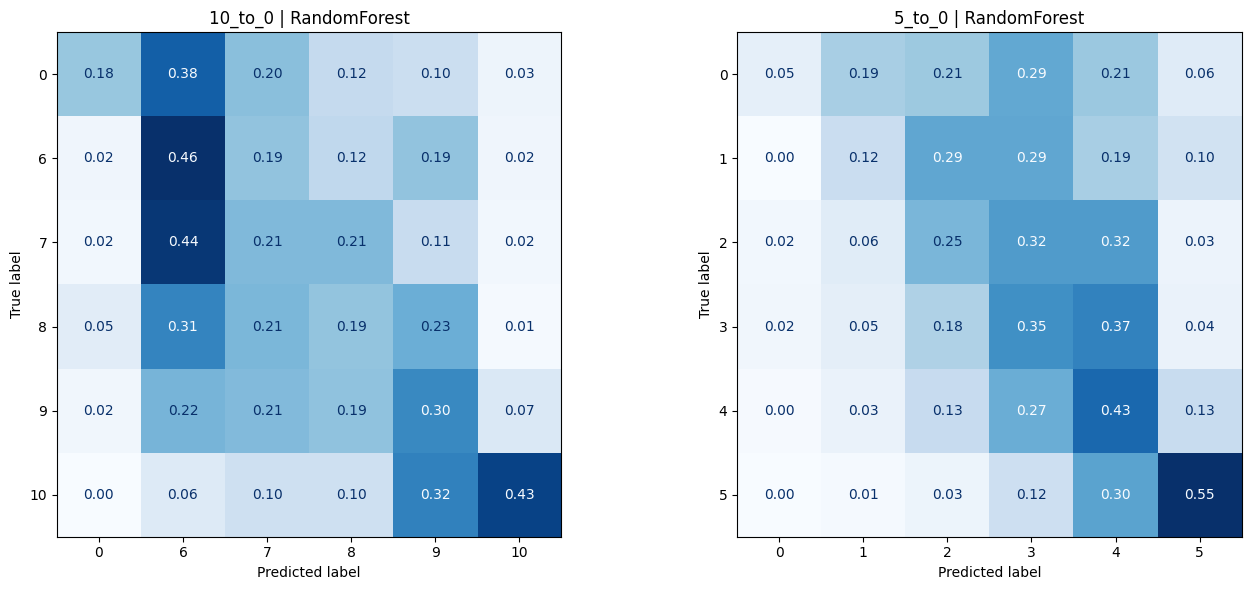

In [41]:
fig, axes = plt.subplots(1, len(df_best_model_per_scale), figsize=(7 * len(df_best_model_per_scale), 6))
if len(df_best_model_per_scale) == 1:
    axes = [axes]

for ax, best_row in zip(axes, df_best_model_per_scale.itertuples()):
    scheme_cfg = next(s for s in SCORE_SCHEMES if s["label"] == best_row.scheme)
    y_true = df_oof_eval[f"{scheme_cfg['scheme']}_true"].astype(int)
    y_pred = df_oof_eval[best_row.prediction_col].astype(float)
    valid_mask = y_pred.notna()

    y_true_valid = y_true.loc[valid_mask].to_numpy()
    y_pred_valid = snap_predictions_to_allowed_scores(
        y_pred.loc[valid_mask].to_numpy(),
        scheme_cfg["valid_scores"],
    )

    cm = confusion_matrix(
        y_true_valid,
        y_pred_valid,
        labels=scheme_cfg["valid_scores"],
        normalize="true",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=scheme_cfg["valid_scores"],
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{best_row.scheme} | {best_row.model}")

plt.tight_layout()
plt.show()


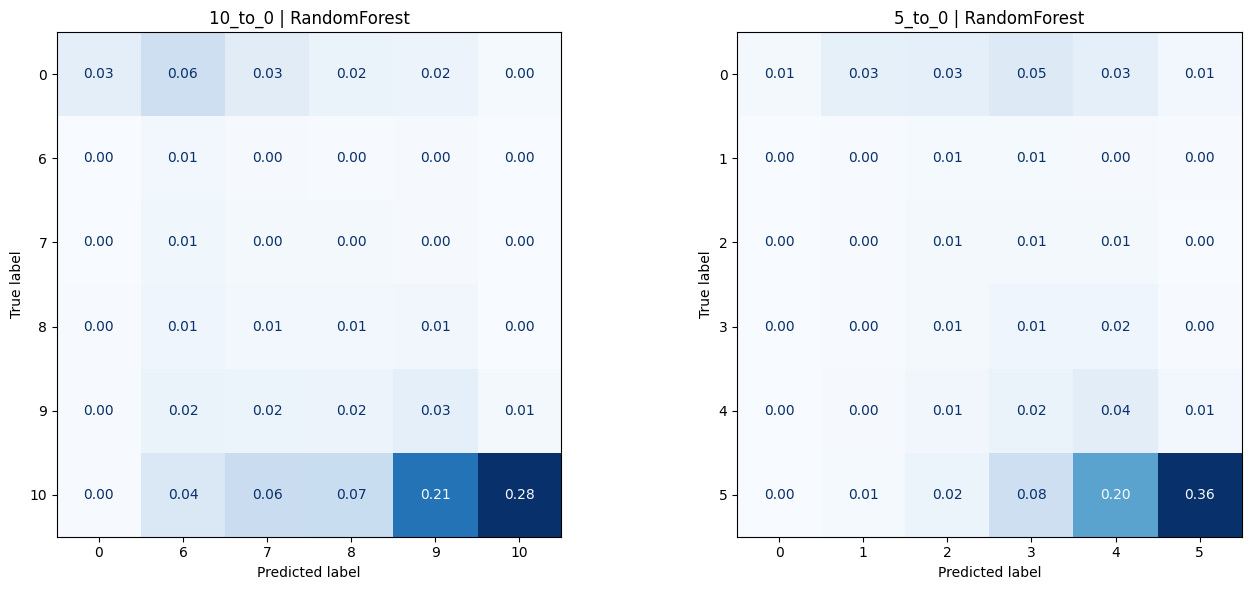

In [40]:
fig, axes = plt.subplots(1, len(df_best_model_per_scale), figsize=(7 * len(df_best_model_per_scale), 6))
if len(df_best_model_per_scale) == 1:
    axes = [axes]

for ax, best_row in zip(axes, df_best_model_per_scale.itertuples()):
    scheme_cfg = next(s for s in SCORE_SCHEMES if s["label"] == best_row.scheme)
    y_true = df_oof_eval[f"{scheme_cfg['scheme']}_true"].astype(int)
    y_pred = df_oof_eval[best_row.prediction_col].astype(float)
    valid_mask = y_pred.notna()

    y_true_valid = y_true.loc[valid_mask].to_numpy()
    y_pred_valid = snap_predictions_to_allowed_scores(
        y_pred.loc[valid_mask].to_numpy(),
        scheme_cfg["valid_scores"],
    )

    cm = confusion_matrix(
        y_true_valid,
        y_pred_valid,
        labels=scheme_cfg["valid_scores"],
        normalize="all",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=scheme_cfg["valid_scores"],
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{best_row.scheme} | {best_row.model}")

plt.tight_layout()
plt.show()


## Conclusions

This notebook now compares both scoring targets directly inside the same workflow:

- the original sparse `10_to_0` target,
- the compact `5_to_0` target,
- repeated-CV performance by model,
- threshold behavior for rejection strategies,
- and confusion matrices for both cases.

Use `df_best_model_per_scale` to compare the best model inside each scale, and `df_best_overall_scale` to choose which target scale is more promising for production.
